# scSketch comparison against trajectory-inference pseudotime

This companion notebook compares saved scSketch directional selections against independently computed pseudotime estimates from PAGA/DPT, Slingshot, and Monocle3. The comparison keeps the scSketch interaction fixed: the same selected cells and same saved scSketch drawing path are joined to each method's pseudotime by `obs_name`.

In [1]:
from pathlib import Path
import json
import re

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse, stats

plt.rcParams.update({
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Inputs

The notebook reuses the existing PAGA/scSketch baseline outputs plus the clean R-generated Slingshot and Monocle3 pseudotime files.

In [2]:
DATASET_NAME = "trajectory_task_dataset_v1_participant"

REVISION_DIR_CANDIDATES = [
    Path("."),
    Path("Manuscript/revision_analyses"),
]
REVISION_DIR = next(
    (
        path
        for path in REVISION_DIR_CANDIDATES
        if (path / "outputs" / DATASET_NAME).exists()
    ),
    None,
)
if REVISION_DIR is None:
    checked = "; ".join(str(path) for path in REVISION_DIR_CANDIDATES)
    raise FileNotFoundError(f"Could not find revision outputs under: {checked}")

BASE_OUTPUT_DIR = REVISION_DIR / "outputs" / DATASET_NAME
PAGA_DIR = BASE_OUTPUT_DIR / "paga_scsketch_comparison_baseline"
TRAJECTORY_DIR = BASE_OUTPUT_DIR / "trajectory_inference_methods"
OUTPUT_DIR = BASE_OUTPUT_DIR / "trajectory_method_scsketch_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_H5AD = PAGA_DIR / "paga_dpt_processed_hvg.h5ad"
SESSION_PATH = PAGA_DIR / "scsketch_on_paga_umap.scsketch.json"

required_inputs = [
    PROCESSED_H5AD,
    SESSION_PATH,
    PAGA_DIR / "paga_dpt_cell_annotations.csv",
    TRAJECTORY_DIR / "slingshot_pseudotime.csv",
    TRAJECTORY_DIR / "monocle3_global_pseudotime.csv",
]
missing = [path for path in required_inputs if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required inputs:\n" + "\n".join(str(path) for path in missing))

TOP_N_VALUES = [25, 50, 100, 200]
PRIMARY_METHODS = ["PAGA/DPT", "Slingshot", "Monocle3 global"]
INCLUDE_MONOCLE3_PARTITIONED = (TRAJECTORY_DIR / "monocle3_partitioned_pseudotime.csv").exists()

print(f"Using processed AnnData: {PROCESSED_H5AD}")
print(f"Using scSketch session: {SESSION_PATH}")
print(f"Writing outputs to: {OUTPUT_DIR}")

Using processed AnnData: outputs/trajectory_task_dataset_v1_participant/paga_scsketch_comparison_baseline/paga_dpt_processed_hvg.h5ad
Using scSketch session: outputs/trajectory_task_dataset_v1_participant/paga_scsketch_comparison_baseline/scsketch_on_paga_umap.scsketch.json
Writing outputs to: outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison


## Load dataset, selections, and pseudotime tables

In [3]:
adata = ad.read_h5ad(PROCESSED_H5AD)
if adata.raw is None:
    raise ValueError("Expected raw expression in the processed AnnData object for all-gene ranking.")
if "X_umap" not in adata.obsm:
    raise KeyError("Expected adata.obsm['X_umap'] for projecting cells onto saved scSketch paths.")

raw = adata.raw.to_adata()
raw = raw[adata.obs_names].copy()
obs_index = pd.Index(adata.obs_names.astype(str))
raw_obs_index = pd.Index(raw.obs_names.astype(str))

session_doc = json.loads(SESSION_PATH.read_text())
session_by_name = {
    selection.get("name", ""): selection
    for selection in session_doc.get("selections", [])
}

selection_files = sorted(PAGA_DIR.glob("scsketch_on_paga_umap_selection_*_selected_cells.csv"))
gene_files = sorted(PAGA_DIR.glob("scsketch_on_paga_umap_selection_*_directional_genes.csv"))

def slug_from_path(path):
    match = re.search(r"scsketch_on_paga_umap_(selection_\d+)_(selected_cells|directional_genes)\.csv", path.name)
    if not match:
        raise ValueError(f"Could not parse selection slug from {path}")
    return match.group(1)

selection_cell_files = {slug_from_path(path): path for path in selection_files}
selection_gene_files = {slug_from_path(path): path for path in gene_files}
selection_slugs = sorted(set(selection_cell_files).intersection(selection_gene_files))
if not selection_slugs:
    raise FileNotFoundError("No paired scSketch selected-cell and directional-gene exports found.")

print(f"AnnData cells: {adata.n_obs:,}; raw genes: {raw.n_vars:,}")
print("Selections:", selection_slugs)

AnnData cells: 6,188; raw genes: 20,222
Selections: ['selection_1', 'selection_2', 'selection_3']


In [4]:
def load_pseudotime_tables():
    tables = []

    paga = pd.read_csv(PAGA_DIR / "paga_dpt_cell_annotations.csv")
    tables.append({
        "method": "PAGA/DPT",
        "primary": True,
        "table": paga[["obs_name", "dpt_pseudotime"]].rename(columns={"dpt_pseudotime": "pseudotime"}),
    })

    slingshot = pd.read_csv(TRAJECTORY_DIR / "slingshot_pseudotime.csv")
    tables.append({
        "method": "Slingshot",
        "primary": True,
        "table": slingshot[["obs_name", "pseudotime"]],
    })

    monocle_global = pd.read_csv(TRAJECTORY_DIR / "monocle3_global_pseudotime.csv")
    tables.append({
        "method": "Monocle3 global",
        "primary": True,
        "table": monocle_global[["obs_name", "pseudotime"]],
    })

    if INCLUDE_MONOCLE3_PARTITIONED:
        monocle_partitioned = pd.read_csv(TRAJECTORY_DIR / "monocle3_partitioned_pseudotime.csv")
        tables.append({
            "method": "Monocle3 partitioned",
            "primary": False,
            "table": monocle_partitioned[["obs_name", "pseudotime"]],
        })

    pseudotime_by_method = {}
    primary_by_method = {}
    for item in tables:
        table = item["table"].copy()
        table["obs_name"] = table["obs_name"].astype(str)
        table["pseudotime"] = pd.to_numeric(table["pseudotime"], errors="coerce")
        pseudotime_by_method[item["method"]] = table.set_index("obs_name")["pseudotime"]
        primary_by_method[item["method"]] = item["primary"]
    return pseudotime_by_method, primary_by_method

pseudotime_by_method, primary_by_method = load_pseudotime_tables()
for method, values in pseudotime_by_method.items():
    matched = values.reindex(obs_index)
    print(f"{method}: {np.isfinite(matched.to_numpy(dtype=float)).sum():,}/{adata.n_obs:,} finite pseudotime values")

PAGA/DPT: 6,188/6,188 finite pseudotime values
Slingshot: 6,188/6,188 finite pseudotime values
Monocle3 global: 6,188/6,188 finite pseudotime values
Monocle3 partitioned: 6,188/6,188 finite pseudotime values


## Helper functions

The path-progress helper projects each selected cell onto the saved scSketch polyline and rescales position along that path to `[0, 1]`. Gene rankings use Pearson correlation between expression and each method's pseudotime among the selected cells.

In [5]:
def safe_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def project_points_to_polyline(points, polyline):
    points = np.asarray(points, dtype=float)
    polyline = np.asarray(polyline, dtype=float)
    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError("points must have shape (n_points, 2)")
    if polyline.ndim != 2 or polyline.shape[0] < 2 or polyline.shape[1] != 2:
        return np.full(points.shape[0], np.nan)

    starts = polyline[:-1]
    ends = polyline[1:]
    segments = ends - starts
    lengths = np.linalg.norm(segments, axis=1)
    keep = lengths > 0
    starts = starts[keep]
    segments = segments[keep]
    lengths = lengths[keep]
    if len(lengths) == 0:
        return np.full(points.shape[0], np.nan)

    cumulative = np.concatenate([[0.0], np.cumsum(lengths)])
    total_length = cumulative[-1]
    best_distance = np.full(points.shape[0], np.inf)
    best_position = np.full(points.shape[0], np.nan)

    for segment_index, (start, segment, length) in enumerate(zip(starts, segments, lengths)):
        rel = points - start
        t = np.clip((rel @ segment) / (length ** 2), 0.0, 1.0)
        projection = start + t[:, None] * segment
        distance = np.linalg.norm(points - projection, axis=1)
        improved = distance < best_distance
        best_distance[improved] = distance[improved]
        best_position[improved] = cumulative[segment_index] + t[improved] * length

    return best_position / total_length


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan, dtype=float)
    valid = np.isfinite(p_values)
    if not valid.any():
        return q_values
    valid_p = p_values[valid]
    order = np.argsort(valid_p)
    ranked = valid_p[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty_like(adjusted)
    restored[order] = adjusted
    q_values[valid] = restored
    return q_values


def pearson_by_gene(X, y):
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(y)
    X = X[valid]
    y = y[valid]
    n = len(y)
    if n < 3 or np.nanstd(y) == 0:
        n_genes = X.shape[1]
        return np.full(n_genes, np.nan), np.full(n_genes, np.nan)

    y_centered = y - y.mean()
    y_ss = np.sum(y_centered ** 2)

    if sparse.issparse(X):
        X = X.tocsr()
        x_sum = np.asarray(X.sum(axis=0)).ravel()
        x_sq_sum = np.asarray(X.power(2).sum(axis=0)).ravel()
        xy_sum = np.asarray(X.T @ y_centered).ravel()
    else:
        X = np.asarray(X, dtype=float)
        x_sum = X.sum(axis=0)
        x_sq_sum = np.sum(X ** 2, axis=0)
        xy_sum = X.T @ y_centered

    x_ss = x_sq_sum - (x_sum ** 2 / n)
    denom = np.sqrt(np.maximum(x_ss, 0) * y_ss)
    r = np.divide(xy_sum, denom, out=np.full_like(xy_sum, np.nan, dtype=float), where=denom > 0)
    r = np.clip(r, -1.0, 1.0)
    df = n - 2
    t_stat = r * np.sqrt(df / np.maximum(1 - r ** 2, 1e-300))
    p_values = 2 * stats.t.sf(np.abs(t_stat), df=df)
    p_values[~np.isfinite(r)] = np.nan
    return r, p_values


def rank_genes_for_cells(obs_names, pseudotime_values):
    obs_names = pd.Index(pd.Series(obs_names, dtype=str))
    positions = raw_obs_index.get_indexer(obs_names)
    present = positions >= 0
    positions = positions[present]
    y = np.asarray(pseudotime_values, dtype=float)[present]
    valid = np.isfinite(y)
    if valid.sum() < 3:
        raise ValueError("Need at least three finite pseudotime values to rank genes.")

    X = raw.X[positions, :]
    r, p_values = pearson_by_gene(X, y)
    ranking = pd.DataFrame({
        "gene": raw.var_names.astype(str),
        "gene_short_name": raw.var["gene_short_name"].astype(str).to_numpy()
        if "gene_short_name" in raw.var.columns
        else raw.var_names.astype(str),
        "pseudotime_correlation": r,
        "p_value": p_values,
        "q_value": benjamini_hochberg(p_values),
    })
    ranking["abs_correlation"] = ranking["pseudotime_correlation"].abs()
    return ranking.sort_values(["q_value", "abs_correlation"], ascending=[True, False])


def sorted_scsketch_genes(table):
    result = table.copy()
    result["gene"] = result["gene"].astype(str)
    result["gene_short_name"] = result.get("gene_short_name", result["gene"]).astype(str)
    result["scsketch_correlation"] = pd.to_numeric(result["correlation"], errors="coerce")
    result["abs_scsketch_correlation"] = result["scsketch_correlation"].abs()
    return result.sort_values("abs_scsketch_correlation", ascending=False)

## Selection-level pseudotime agreement and gene-overlap analysis

In [6]:
agreement_rows = []
overlap_rows = []
shared_gene_rows = []
revision_rows = []

for slug in selection_slugs:
    selected_cells = pd.read_csv(selection_cell_files[slug])
    scsketch_genes = sorted_scsketch_genes(pd.read_csv(selection_gene_files[slug]))
    if selected_cells.empty or scsketch_genes.empty:
        print(f"Skipping {slug}: missing selected cells or directional genes.")
        continue

    selection_name = selected_cells["selection"].iloc[0] if "selection" in selected_cells.columns else slug.replace("_", " ").title()
    selected_obs = selected_cells["obs_name"].astype(str).tolist()
    selected_obs = [obs for obs in selected_obs if obs in obs_index]
    if not selected_obs:
        print(f"Skipping {selection_name}: no selected cells match AnnData obs_names.")
        continue

    selected_positions = obs_index.get_indexer(selected_obs)
    path = session_by_name.get(selection_name, {}).get("path") or []
    progress = project_points_to_polyline(adata.obsm["X_umap"][selected_positions, :2], path)
    progress_by_obs = pd.Series(progress, index=selected_obs, name="scsketch_path_progress")

    selection_method_summary = {}

    for method, pseudotime_series in pseudotime_by_method.items():
        method_safe = safe_name(method)
        method_pseudotime = pseudotime_series.reindex(selected_obs).to_numpy(dtype=float)
        finite = np.isfinite(progress) & np.isfinite(method_pseudotime)
        if finite.sum() >= 3:
            spearman = stats.spearmanr(progress[finite], method_pseudotime[finite])
            pearson = stats.pearsonr(progress[finite], method_pseudotime[finite])
            spearman_r = float(spearman.statistic)
            spearman_p = float(spearman.pvalue)
            pearson_r = float(pearson.statistic)
            pearson_p = float(pearson.pvalue)
        else:
            spearman_r = spearman_p = pearson_r = pearson_p = np.nan

        orientation_sign = 1.0 if not np.isfinite(spearman_r) or spearman_r >= 0 else -1.0
        selection_method_summary[method] = {
            "n_valid": int(finite.sum()),
            "spearman_r": spearman_r,
            "orientation_sign": orientation_sign,
        }

        agreement_rows.append({
            "selection": selection_name,
            "method": method,
            "primary_method": primary_by_method[method],
            "selected_cells": len(selected_obs),
            "n_finite_progress_and_pseudotime": int(finite.sum()),
            "path_progress_pseudotime_spearman_r": spearman_r,
            "path_progress_pseudotime_spearman_p": spearman_p,
            "path_progress_pseudotime_pearson_r": pearson_r,
            "path_progress_pseudotime_pearson_p": pearson_p,
        })

        ranking = rank_genes_for_cells(selected_obs, method_pseudotime)
        ranking.insert(0, "method", method)
        ranking.insert(0, "selection", selection_name)
        ranking_path = OUTPUT_DIR / f"{safe_name(selection_name)}_{method_safe}_gene_ranking.csv"
        ranking.to_csv(ranking_path, index=False)

        for top_n in TOP_N_VALUES:
            top_scsketch = scsketch_genes.head(top_n)["gene"].astype(str).tolist()
            top_method = ranking.head(top_n)["gene"].astype(str).tolist()
            overlap = sorted(set(top_scsketch).intersection(top_method))
            union = set(top_scsketch).union(top_method)
            overlap_rows.append({
                "selection": selection_name,
                "method": method,
                "primary_method": primary_by_method[method],
                "top_n": top_n,
                "scsketch_genes": len(top_scsketch),
                "method_genes": len(top_method),
                "overlap": len(overlap),
                "overlap_fraction": len(overlap) / top_n,
                "jaccard": len(overlap) / len(union) if union else np.nan,
                "scsketch_rank_metric": "abs_scsketch_correlation",
                "method_rank_metric": "q_value_then_abs_pseudotime_correlation",
                "path_progress_pseudotime_spearman_r": spearman_r,
            })

        top100_scsketch = scsketch_genes.head(100).copy()
        top100_method = ranking.head(100).copy()
        shared = top100_scsketch.merge(
            top100_method,
            on="gene",
            suffixes=("_scsketch", "_method"),
        )
        for rank, row in enumerate(shared.itertuples(index=False), start=1):
            shared_gene_rows.append({
                "selection": selection_name,
                "method": method,
                "primary_method": primary_by_method[method],
                "shared_rank": rank,
                "gene": row.gene,
                "gene_short_name": getattr(row, "gene_short_name_method", getattr(row, "gene_short_name_scsketch", row.gene)),
                "scsketch_correlation": row.scsketch_correlation,
                "orientation_adjusted_scsketch_correlation": row.scsketch_correlation * orientation_sign,
                "method_pseudotime_correlation": row.pseudotime_correlation,
                "method_q_value": row.q_value,
                "path_progress_pseudotime_spearman_r": spearman_r,
            })

    for method in pseudotime_by_method:
        method_rows = [
            row for row in overlap_rows
            if row["selection"] == selection_name and row["method"] == method
        ]
        top_shared = [
            row["gene_short_name"] for row in shared_gene_rows
            if row["selection"] == selection_name and row["method"] == method
        ][:10]
        revision_row = {
            "selection": selection_name,
            "method": method,
            "primary_method": primary_by_method[method],
            "selected_cells": len(selected_obs),
            "n_finite_progress_and_pseudotime": selection_method_summary[method]["n_valid"],
            "path_progress_pseudotime_spearman_r": selection_method_summary[method]["spearman_r"],
            "top_shared_genes": ", ".join(top_shared),
        }
        for top_n in TOP_N_VALUES:
            row = next(row for row in method_rows if row["top_n"] == top_n)
            revision_row[f"top{top_n}_overlap"] = row["overlap"]
            revision_row[f"top{top_n}_overlap_fraction"] = row["overlap_fraction"]
            revision_row[f"top{top_n}_jaccard"] = row["jaccard"]
        revision_rows.append(revision_row)

agreement = pd.DataFrame(agreement_rows)
overlap_summary = pd.DataFrame(overlap_rows)
shared_top100 = pd.DataFrame(shared_gene_rows)
revision_summary = pd.DataFrame(revision_rows)

agreement.to_csv(OUTPUT_DIR / "trajectory_method_selection_agreement.csv", index=False)
overlap_summary.to_csv(OUTPUT_DIR / "trajectory_method_gene_overlap_summary.csv", index=False)
shared_top100.to_csv(OUTPUT_DIR / "trajectory_method_shared_top100_genes.csv", index=False)
revision_summary.to_csv(OUTPUT_DIR / "trajectory_method_revision_summary.csv", index=False)
primary_revision_summary = revision_summary.loc[revision_summary["primary_method"]].copy()
primary_revision_summary.to_csv(
    OUTPUT_DIR / "trajectory_method_revision_summary_primary.csv",
    index=False,
)

print(f"Wrote {len(agreement):,} selection-method agreement rows")
print(f"Wrote {len(overlap_summary):,} gene-overlap summary rows")
print(f"Wrote {len(shared_top100):,} shared top-100 gene rows")
display(primary_revision_summary.sort_values(["selection", "method"]))

Wrote 12 selection-method agreement rows
Wrote 48 gene-overlap summary rows
Wrote 484 shared top-100 gene rows


,selection,method,primary_method,selected_cells,n_finite_progress_and_pseudotime,path_progress_pseudotime_spearman_r,top_shared_genes,top25_overlap,top25_overlap_fraction,top25_jaccard,top50_overlap,top50_overlap_fraction,top50_jaccard,top100_overlap,top100_overlap_fraction,top100_jaccard,top200_overlap,top200_overlap_fraction,top200_jaccard
2,Selection 1,Monocle3 global,True,625,625,0.966904,"eri-6, C33A12.4, dmd-5, xbx-9, pghm-1, sto-1, ...",12,0.48,0.315789,24,0.48,0.315789,43,0.43,0.273885,76,0.380,0.234568
0,Selection 1,PAGA/DPT,True,625,625,0.974078,"eri-6, C33A12.4, dmd-5, xbx-9, pghm-1, sto-1, ...",17,0.68,0.515152,30,0.60,0.428571,56,0.56,0.388889,103,0.515,0.346801
1,Selection 1,Slingshot,True,625,625,0.939664,"eri-6, C33A12.4, dmd-5, xbx-9, pghm-1, sto-1, ...",16,0.64,0.470588,28,0.56,0.388889,50,0.50,0.333333,95,0.475,0.311475
6,Selection 2,Monocle3 global,True,996,996,0.855303,"C33A12.4, lbp-1, his-24, clec-266, hil-7, C34E...",8,0.32,0.190476,15,0.30,0.176471,32,0.32,0.190476,59,0.295,0.173021
4,Selection 2,PAGA/DPT,True,996,996,0.874547,"C33A12.4, lbp-1, his-24, clec-266, hil-7, K08C...",11,0.44,0.282051,25,0.50,0.333333,45,0.45,0.290323,78,0.390,0.242236
5,Selection 2,Slingshot,True,996,996,0.853344,"C33A12.4, lbp-1, his-24, clec-266, hil-7, C34E...",9,0.36,0.219512,19,0.38,0.234568,36,0.36,0.219512,63,0.315,0.186944
10,Selection 3,Monocle3 global,True,483,483,0.928216,"C33A12.4, ins-2, ces-1, C02B4.4, flp-27, osm-1...",13,0.52,0.351351,21,0.42,0.265823,41,0.41,0.257862,80,0.400,0.250000
8,Selection 3,PAGA/DPT,True,483,483,0.988871,"C33A12.4, ins-2, ces-1, C02B4.4, flp-27, osm-1...",13,0.52,0.351351,23,0.46,0.298701,41,0.41,0.257862,85,0.425,0.269841
9,Selection 3,Slingshot,True,483,483,0.980284,"C33A12.4, ins-2, ces-1, C02B4.4, flp-27, osm-1...",13,0.52,0.351351,23,0.46,0.298701,43,0.43,0.273885,83,0.415,0.261830


## Method-level pseudotime QC summary

In [7]:
qc_rows = []

paga_qc = pd.read_csv(PAGA_DIR / "pseudotime_validation_summary.csv")
qc_rows.append({
    "method": "PAGA/DPT",
    "primary_method": True,
    "n_cells": int(paga_qc["n_cells_with_finite_embryo_time_and_dpt"].iloc[0]),
    "n_finite_pseudotime": int(paga_qc["n_cells_with_finite_embryo_time_and_dpt"].iloc[0]),
    "spearman_vs_embryo_time": float(paga_qc["spearman_r"].iloc[0]),
    "note": "DPT root selected from earliest-median Leiden cluster.",
})

slingshot_qc = pd.read_csv(TRAJECTORY_DIR / "slingshot_pseudotime_summary.csv")
qc_rows.append({
    "method": "Slingshot",
    "primary_method": True,
    "n_cells": int(slingshot_qc["n_cells"].iloc[0]),
    "n_finite_pseudotime": int(slingshot_qc["n_finite_pseudotime"].iloc[0]),
    "spearman_vs_embryo_time": float(slingshot_qc["spearman_vs_embryo_time"].iloc[0]),
    "note": f"PCA Slingshot, start cluster {slingshot_qc['start_cluster'].iloc[0]}, {slingshot_qc['n_lineages'].iloc[0]} lineages.",
})

for label, filename, primary in [
    ("Monocle3 global", "monocle3_global_pseudotime_summary.csv", True),
    ("Monocle3 partitioned", "monocle3_partitioned_pseudotime_summary.csv", False),
]:
    path = TRAJECTORY_DIR / filename
    if path.exists():
        table = pd.read_csv(path)
        qc_rows.append({
            "method": label,
            "primary_method": primary,
            "n_cells": int(table["n_cells"].iloc[0]),
            "n_finite_pseudotime": int(table["n_finite_pseudotime"].iloc[0]),
            "spearman_vs_embryo_time": float(table["spearman_vs_embryo_time"].iloc[0]),
            "note": table["root_selection_note"].iloc[0],
        })

method_qc = pd.DataFrame(qc_rows)
method_qc.to_csv(OUTPUT_DIR / "trajectory_method_pseudotime_qc_summary.csv", index=False)
display(method_qc)

,method,primary_method,n_cells,n_finite_pseudotime,spearman_vs_embryo_time,note
0,PAGA/DPT,True,6188,6188,0.869491,DPT root selected from earliest-median Leiden ...
1,Slingshot,True,6188,6188,0.877292,"PCA Slingshot, start cluster 2, 13 lineages."
2,Monocle3 global,True,6188,6188,0.874848,A single root was selected from early embryo-t...
3,Monocle3 partitioned,False,6188,6188,0.258873,Roots were selected from early embryo-time cel...


## Reviewer-facing summary figure

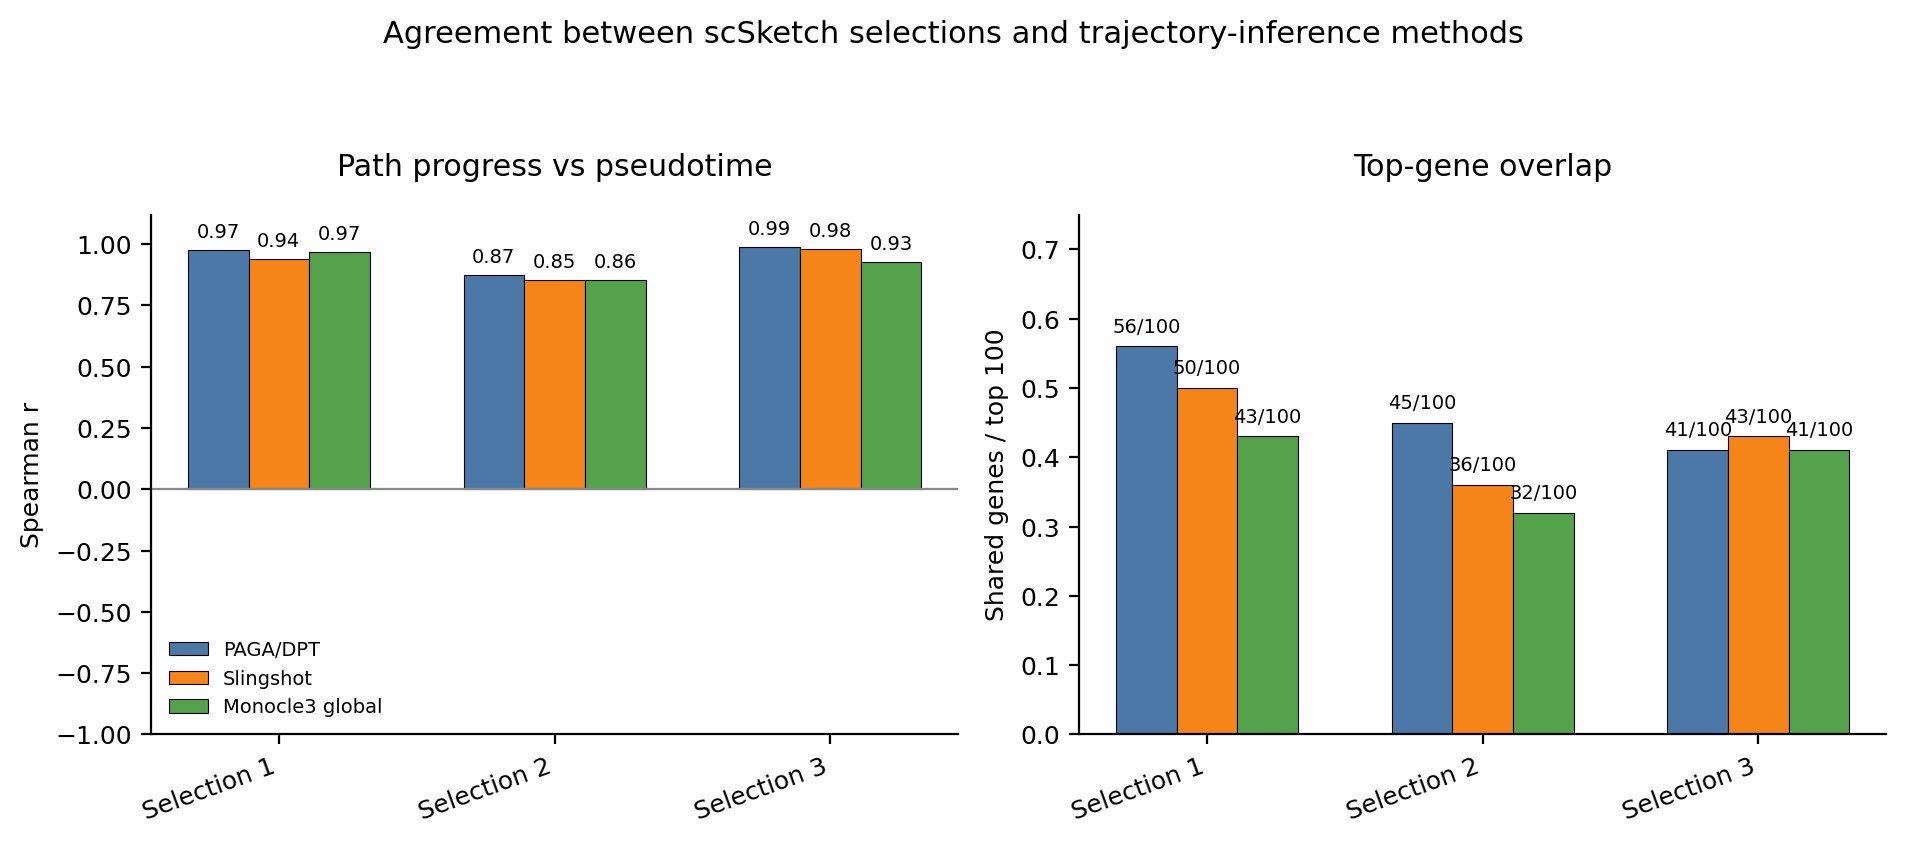

Wrote figure: outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_revision_summary_figure.png
Wrote figure: outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_revision_summary_figure.pdf


In [8]:
plot_summary = revision_summary.loc[revision_summary["method"].isin(PRIMARY_METHODS)].copy()
selection_order = ["Selection 1", "Selection 2", "Selection 3"]
selection_order = [selection for selection in selection_order if selection in set(plot_summary["selection"])]
method_order = [method for method in PRIMARY_METHODS if method in set(plot_summary["method"])]
method_colors = {
    "PAGA/DPT": "#4C78A8",
    "Slingshot": "#F58518",
    "Monocle3 global": "#54A24B",
}

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2), dpi=200)
bar_width = 0.22
x = np.arange(len(selection_order))
offsets = np.linspace(-bar_width, bar_width, len(method_order))

for offset, method in zip(offsets, method_order):
    values = []
    labels = []
    for selection in selection_order:
        row = plot_summary.loc[
            (plot_summary["selection"] == selection) &
            (plot_summary["method"] == method)
        ].iloc[0]
        values.append(row["path_progress_pseudotime_spearman_r"])
        labels.append(f"{row['path_progress_pseudotime_spearman_r']:.2f}")
    bars = axes[0].bar(
        x + offset,
        values,
        width=bar_width,
        label=method,
        color=method_colors.get(method, "#777777"),
        edgecolor="black",
        linewidth=0.4,
    )
    for bar, label in zip(bars, labels):
        y = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            y + (0.035 if y >= 0 else -0.06),
            label,
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=7,
            rotation=0,
        )

axes[0].axhline(0, color="#888888", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(selection_order, rotation=20, ha="right")
axes[0].set_ylim(-1.0, 1.12)
axes[0].set_ylabel("Spearman r")
axes[0].set_title("Path progress vs pseudotime", pad=14)
axes[0].legend(frameon=False, fontsize=7)

for offset, method in zip(offsets, method_order):
    values = []
    labels = []
    for selection in selection_order:
        row = plot_summary.loc[
            (plot_summary["selection"] == selection) &
            (plot_summary["method"] == method)
        ].iloc[0]
        values.append(row["top100_overlap_fraction"])
        labels.append(f"{int(row['top100_overlap'])}/100")
    bars = axes[1].bar(
        x + offset,
        values,
        width=bar_width,
        label=method,
        color=method_colors.get(method, "#777777"),
        edgecolor="black",
        linewidth=0.4,
    )
    for bar, label in zip(bars, labels):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            label,
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=0,
        )

axes[1].set_xticks(x)
axes[1].set_xticklabels(selection_order, rotation=20, ha="right")
axes[1].set_ylim(0, max(0.75, plot_summary["top100_overlap_fraction"].max() + 0.12))
axes[1].set_ylabel("Shared genes / top 100")
axes[1].set_title("Top-gene overlap", pad=14)

fig.suptitle("Agreement between scSketch selections and trajectory-inference methods", fontsize=11, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUTPUT_DIR / "trajectory_method_revision_summary_figure.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "trajectory_method_revision_summary_figure.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Wrote figure: {OUTPUT_DIR / 'trajectory_method_revision_summary_figure.png'}")
print(f"Wrote figure: {OUTPUT_DIR / 'trajectory_method_revision_summary_figure.pdf'}")

## Output files

In [9]:
expected_outputs = [
    "trajectory_method_selection_agreement.csv",
    "trajectory_method_gene_overlap_summary.csv",
    "trajectory_method_shared_top100_genes.csv",
    "trajectory_method_revision_summary.csv",
    "trajectory_method_revision_summary_primary.csv",
    "trajectory_method_pseudotime_qc_summary.csv",
    "trajectory_method_revision_summary_figure.png",
    "trajectory_method_revision_summary_figure.pdf",
]
for filename in expected_outputs:
    path = OUTPUT_DIR / filename
    print(f"{path} {'OK' if path.exists() else 'MISSING'}")

outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_selection_agreement.csv OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_gene_overlap_summary.csv OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_shared_top100_genes.csv OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_revision_summary.csv OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_revision_summary_primary.csv OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_pseudotime_qc_summary.csv OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_comparison/trajectory_method_revision_summary_figure.png OK
outputs/trajectory_task_dataset_v1_participant/trajectory_method_scsketch_compari